## General

In [1]:
from collections import defaultdict
import json, math
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [2]:
# Load data
with open('../record/finalstep_stats_3.json') as f:
    data = json.load(f)
with open('../record/finalrandla_stats_3.json') as f2:
    data2 = json.load(f2)
with open('../record/finalmean_stats_3.json') as f3:
    data3 = json.load(f3)
with open('../record/finalmax_stats_3.json') as f4:
    data4 = json.load(f4)
with open('../record/finalmean_stats_3.json') as f5:
    data5 = json.load(f5)
with open('../record/finalcombine_stats_3.json') as f6:
    data6 = json.load(f6)
def euclidean(p1, p2):
    return math.sqrt((p1[0] - p2[0])**2 + (p1[1] - p2[1])**2)


# Environment mapping: (start_point, goal_point) with  environment name
env_map = {
    ((-30, 7), (-22, 17)): "normal",
    ((-30, -20), (-22, -6)): "uneven",
    ((-31, -44), (-20, -37)): "mutlti ramp",
    ((-55, 5), (-41, 5)): "two_height_ramp",
    ((-33, 40), (-20, 40)): "ramp_obstacle",
    ((-55, -13), (-41, -13)): "hole",
}

# Function to map (start_point, goal_point) to environment name
def get_env_name(start_point, goal_point, max_snap_dist=5.0):
    # Exact rounded lookup (backwards compatible)
    start_rounded = tuple(round(x) for x in start_point)
    goal_rounded = tuple(round(x) for x in goal_point)
    key = (start_rounded, goal_rounded)

    if key in env_map:
        return env_map[key]

    # Find closest template pair in env_map
    best_name = None
    best_dist = float("inf")

    for (tmpl_start, tmpl_goal), name in env_map.items():
        dist = euclidean(start_point, tmpl_start) + euclidean(goal_point, tmpl_goal)
        if dist < best_dist:
            best_dist = dist
            best_name = name

    # Snap if close enough
    if best_dist <= max_snap_dist:
        return best_name

    # Fallback: keep explicit mapping
    return f"{start_rounded}→{goal_rounded}"


# Process data to compute stats per environment
def process_data(data):
    groups = defaultdict(list)

    for entry in data:
        env_key = get_env_name(entry["start_point"], entry["goal_point"])
        groups[env_key].append(entry)

    stats = {}
    for key, group in groups.items():
        total_lengths = [sum(entry["total_length"]) for entry in group]
        dist_togoals = [entry["dist_to_goal"] for entry in group]
        collision_counts = [entry["collision_count"] for entry in group]
        counts = [entry["count"] for entry in group]
        reach_goals = [entry["reach_goal"] for entry in group]

        # Distances involving current_pos
        dist_start_curr = [
            euclidean(entry["start_point"], entry["current_pos"]) for entry in group
        ]
        dist_curr_goal = [
            euclidean(entry["current_pos"], entry["goal_point"]) for entry in group
        ]

        mean_total_length = sum(total_lengths) / len(total_lengths)
        mean_dist_togoal = sum(dist_togoals) / len(dist_togoals)
        mean_collision = sum(collision_counts) / len(collision_counts)
        mean_count = sum(counts) / len(counts)
        reach_goal_rate = sum(reach_goals) / len(reach_goals)
        N = len(collision_counts)
        if N > 1:
            std_dev = np.std(collision_counts, ddof=1) # Standard Deviation
            sem_collision = std_dev / math.sqrt(N)     # Standard Error
        else:
            sem_collision = 0.0


        mean_start_curr = sum(dist_start_curr) / len(dist_start_curr)
        mean_curr_goal = sum(dist_curr_goal) / len(dist_curr_goal)

        success_collision_counts = [
            entry["collision_count"] for entry in group if entry.get("reach_goal")
        ]
        mean_collision_success = (
            sum(success_collision_counts) / len(success_collision_counts)
            if success_collision_counts else 0.0
        )

        # ---------------------------------------------
        # Flip-over metric:
        #   reach_goal == False AND count != 700
        # ---------------------------------------------
        flip_over_flags = [
            (not entry["reach_goal"]) and (entry["count"] != 700)
            for entry in group
        ]
        flip_over_count = sum(flip_over_flags)          
        flip_over_rate = flip_over_count / len(group) * 100.0  

        stats[key] = {
            "total_length": mean_total_length,
            "dist_togoal": mean_dist_togoal,
            "collision_count": mean_collision,
            "std_collision": sem_collision,
            "count": mean_count,
            "reach_goal_rate": reach_goal_rate * 100,  
            "dist_start_to_current": mean_start_curr,
            "dist_current_to_goal": mean_curr_goal,
            "mean_collision_success": mean_collision_success,
            "flip_over_count": flip_over_count,        
            "flip_over_rate": flip_over_rate,          
        }
    return stats

# Process all datasets
stats1 = process_data(data)
stats2 = process_data(data2)
stats3 = process_data(data3)
stats4 = process_data(data4)
stats5 = process_data(data5)
stats6 = process_data(data6)

In [3]:
# Standardize environment labels using canonical_map and ensure consistent ordering for plotting
plt.rcParams.update({
    'font.size': 14,          
    'axes.titlesize': 12,     
    'axes.labelsize': 12,     
    'xtick.labelsize': 12,    
    'ytick.labelsize': 12,   
    'legend.fontsize': 12, 
    # 'font.family': 'serif',   # Matches typical thesis font (Times New Roman-ish)
})

desired_order = ['Normal', 'Uneven', 'Cliff',  'Multi Ramp', 'Ramp with Obs','Hole']
canonical_map = {

    ((-30, 7), (-22, 17)): "Normal",
    ((-30, -20), (-22, -6)): "Uneven",
    ((-31, -44), (-20, -37)): "Multi Ramp",
    ((-55, 5), (-41, 5)): "Cliff",
    ((-33, 40), (-20, 40)): "Ramp with Obs",
    ((-55, -13), (-41, -13)): "Hole",
    
    # mapping from env_key to canonical label
    "normal": "Normal",
    "uneven": "Uneven",
    "two_height_ramp": "Cliff",         
    "ramp_obstacle": "Ramp with Obs",   
    "mutlti ramp": "Multi Ramp",        
    "multi ramp": "Multi Ramp",
    "hole": "Hole"
}

def relabel_stats(stats):
    new_stats = {}
    for key, values in stats.items():
        # Check if key is in our map 
        if key in canonical_map:
            label = canonical_map[key]
        elif str(key) in canonical_map:
            label = canonical_map[str(key)]
        else:
            # Fallback for unexpected keys
            label = str(key)
            
        new_stats[label] = values
    return new_stats

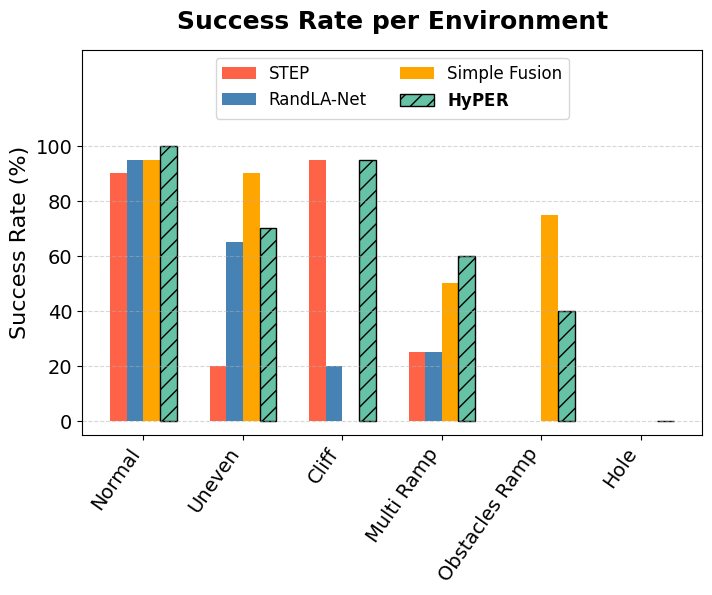

In [4]:
stats1_labeled = relabel_stats(stats1)
stats2_labeled = relabel_stats(stats2)
stats3_labeled = relabel_stats(stats3)
stats4_labeled = relabel_stats(stats4)
stats5_labeled = relabel_stats(stats5)
stats6_labeled = relabel_stats(stats6)

# Combine all labels with custom order (ensure 'normal' first per settings)
label_set = (
    set(stats1_labeled.keys())
    .union(stats2_labeled.keys())
    .union(stats3_labeled.keys())
    .union(stats4_labeled.keys())
    .union(stats5_labeled.keys())
    .union(stats6_labeled.keys())
)
all_labels = [lbl for lbl in desired_order if lbl in label_set] + sorted(label_set - set(desired_order))

# Build series
step_rates    = [stats1_labeled.get(label, {}).get("reach_goal_rate", 0) for label in all_labels]
randla_rates  = [stats2_labeled.get(label, {}).get("reach_goal_rate", 0) for label in all_labels]
combine_rates = [stats3_labeled.get(label, {}).get("reach_goal_rate", 0) for label in all_labels]
full_rates    = [stats4_labeled.get(label, {}).get("reach_goal_rate", 0) for label in all_labels]
test_rates    = [stats5_labeled.get(label, {}).get("reach_goal_rate", 0) for label in all_labels]
new_rates     = [stats6_labeled.get(label, {}).get("reach_goal_rate", 0) for label in all_labels]  # <-- NEW

import numpy as np
import matplotlib.pyplot as plt

# Label Mapping Setup 
env_keys = ['Normal', 'Uneven', 'Cliff', 'Multi Ramp', 'Ramp with Obs', 'Hole']
display_labels = ['Normal', 'Uneven', 'Cliff', 'Multi Ramp', 'Obstacles Ramp', 'Hole']
# Create a mapping dictionary for easy lookup
label_map = dict(zip(env_keys, display_labels))

# Filter labels that actually exist in your data but keep the desired order
all_labels = [lbl for lbl in env_keys if lbl in label_set]
# Generate the display version for the X-axis
xtick_labels = [label_map.get(lbl, lbl) for lbl in all_labels]

# Build Series using the original keys
step_rates    = [stats1_labeled.get(label, {}).get("reach_goal_rate", 0) for label in all_labels]
randla_rates  = [stats2_labeled.get(label, {}).get("reach_goal_rate", 0) for label in all_labels]
combine_rates = [stats3_labeled.get(label, {}).get("reach_goal_rate", 0) for label in all_labels]
# Using stats6 (new_rates) as the primary HyPER series per your previous logic
new_rates     = [stats6_labeled.get(label, {}).get("reach_goal_rate", 0) for label in all_labels]

# Layout adjustments 
group_spacing = 1.2  # Slightly wider to breathe between 6 environments
x = np.arange(len(all_labels)) * group_spacing
width = 0.2  # Width of individual bars

# Centering 4 bars: offsets at -1.5, -0.5, 0.5, 1.5 times the width
offsets = [-1.5 * width, -0.5 * width, 0.5 * width, 1.5 * width]

plt.figure(figsize=(8, 5)) # Slightly wider for 6 groups

# Plotting
plt.bar(x + offsets[0], step_rates,    width, label='STEP', color='tomato')
plt.bar(x + offsets[1], randla_rates,  width, label='RandLA-Net', color='steelblue')
plt.bar(x + offsets[2], combine_rates, width, label='Simple Fusion', color='orange')
plt.bar(
    x + offsets[3], 
    new_rates, 
    width, 
    label=r'$\bf{HyPER}$', 
    color='#66C2A5', 
    edgecolor='black', 
    hatch='//'
)

# Final Touches with New Display Labels
plt.xticks(x, xtick_labels, rotation=55, ha='right', fontsize=14)
plt.yticks(np.arange(0, 101, 20), fontsize=14)
plt.ylabel("Success Rate (%)", fontsize=16)
plt.ylim(-5, 135)

plt.title("Success Rate per Environment", fontsize=18, pad=15, fontweight='bold')
plt.legend(ncol=2, fontsize=12, loc='upper center', frameon=True)
plt.grid(True, axis='y', linestyle='--', alpha=0.5)

# plt.tight_layout()
# plt.savefig("success_rates.pdf", format="pdf", bbox_inches='tight')
# plt.show()
# save as svg
# plt.savefig("success_rates.svg", format="svg", bbox_inches='tight')
plt.show()


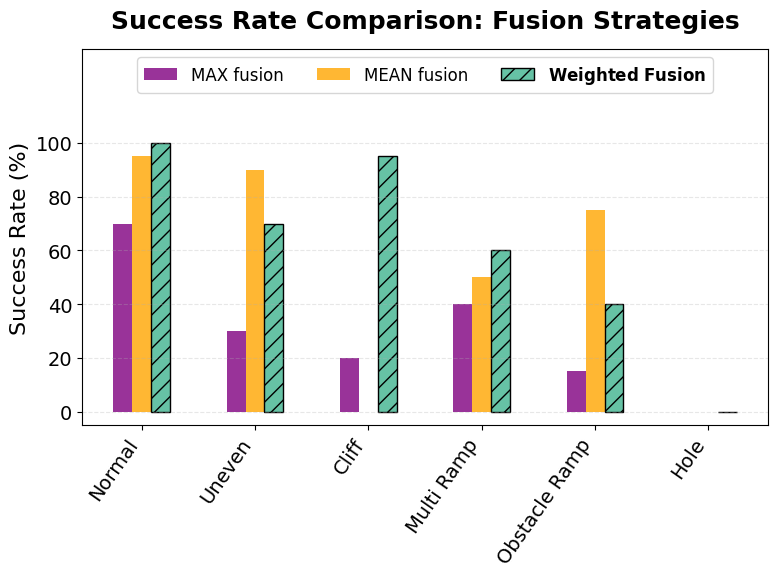

In [5]:

env_map = {
    ((-30, 7), (-22, 17)): "normal",
    ((-30, -20), (-22, -6)): "uneven",
    ((-31, -44), (-20, -37)): "mutlti ramp",
    ((-55, 5), (-41, 5)): "two_height_ramp",
    ((-33, 40), (-20, 40)): "ramp_obstacle",
    ((-55, -13), (-41, -13)): "hole",
}

def relabel_stats(stats):
    new_stats = {}
    for key, values in stats.items():
        if isinstance(key, str):
            label = key
        elif isinstance(key, tuple) and len(key) == 2:
            start, goal = key
            label = env_map.get((start, goal), f"{start}→{goal}")
        else:
            label = str(key)
        new_stats[label] = values
    return new_stats

# Relabel all datasets
stats4_labeled = relabel_stats(stats4)
stats5_labeled = relabel_stats(stats5)
stats6_labeled = relabel_stats(stats6)

# Label Setup & Data Filtering
# Defining keys as they appear in the relabeled dictionaries
env_keys = ['normal', 'uneven', 'two_height_ramp', 'mutlti ramp', 'ramp_obstacle', 'hole']
# Defining how they should look on the chart
display_labels = ['Normal', 'Uneven', 'Cliff','Multi Ramp', 'Obstacle Ramp', 'Hole']
label_map = dict(zip(env_keys, display_labels))

# Determine which labels exist in the provided stats
label_set = set(stats4_labeled.keys()).union(stats5_labeled.keys()).union(stats6_labeled.keys())
all_labels = [lbl for lbl in env_keys if lbl in label_set]
xtick_labels = [label_map.get(lbl, lbl) for lbl in all_labels]

# Build Data Series
max_rates   = [stats4_labeled.get(label, {}).get("reach_goal_rate", 0) for label in all_labels]
mean_rates  = [stats5_labeled.get(label, {}).get("reach_goal_rate", 0) for label in all_labels]
aware_rates = [stats6_labeled.get(label, {}).get("reach_goal_rate", 0) for label in all_labels]

# Plotting Configuration
group_spacing = 1.2
x = np.arange(len(all_labels)) * group_spacing
width = 0.2

# Offsets for 3 bars (MAX at -width, MEAN at 0, AWARE at +width)
offsets = [-1.0 * width, 0.0 * width, 1.0 * width]

plt.figure(figsize=(8, 6))
plt.bar(x + offsets[0], max_rates, width, 
        label='MAX fusion', color='purple', alpha=0.8)

plt.bar(x + offsets[1], mean_rates, width, 
        label='MEAN fusion', color='orange', alpha=0.8)

plt.bar(x + offsets[2], aware_rates, width, 
        label=r'$\bf{Weighted\ Fusion}$', color='#66C2A5', 
        edgecolor='black', hatch='//')

# Styling & Aesthetics
plt.xticks(x, xtick_labels, rotation=55, ha='right', fontsize=14)
plt.yticks(np.arange(0, 101, 20), fontsize=14)
plt.ylabel("Success Rate (%)", fontsize=16)
plt.ylim(-5, 135)  # Height adjusted for legend clearance

plt.title("Success Rate Comparison: Fusion Strategies", fontsize=18, pad=15, fontweight='bold')
plt.legend(ncol=3, fontsize=12, loc='upper center', frameon=True)
plt.grid(True, axis='y', linestyle='--', alpha=0.3)

# Save and Show 
plt.tight_layout()
# plt.savefig("success_rates_fusion_comparison.svg", format="svg", bbox_inches='tight')
plt.show()